In [1]:
# Importamos todas las librerias necesarias para mostrar y filtrar los datos correctamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Usando la libreria pandas leemos el csv y lo guardamos en una variable para poder utilizarlo, luego mostramos que se ha cargado correctamente
df = pd.read_csv("pokemon.csv")
print(f"Dataset carregat: {df.shape[0]} files i {df.shape[1]} columnes.")

In [5]:
# Calcula el promedio de base_stat_total por hábitat y ordena de mayor a menor
habitat_promedio = (
    df.groupby("habitat")["base_stat_total"] # Agrupa por hábitat y selecciona la columna base_stat_total
    .mean() # Promedio de cada grupo
    .reset_index() # Convierte "habitat" de índice a columna normal
    .sort_values(by="base_stat_total", ascending=False) # Ordena de mayor a menor promedio
)

In [19]:
display(habitat_promedio.iloc[[0]])

,habitat,base_stat_total
4,rare,599.6


In [ ]:
habitat_suma = (
    df.groupby("habitat")["base_stat_total"]
    .sum()
    .reset_index()
    .sort_values(by="base_stat_total", ascending=False)
)

In [18]:
display(habitat_suma.iloc[[0]])

,habitat,base_stat_total
2,grassland,32216


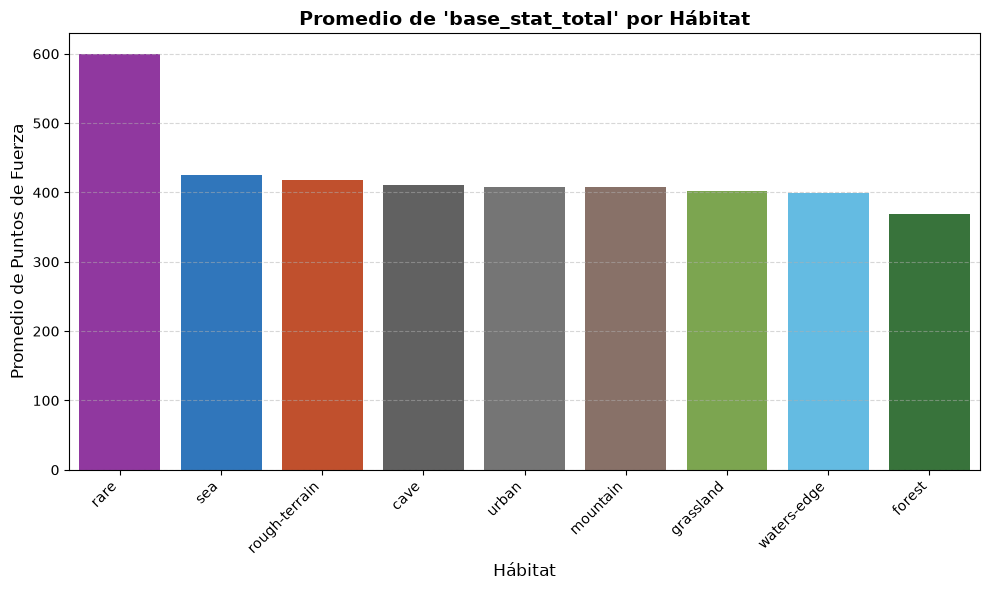

In [12]:
# Diccionario con colores representativos para cada hábitat
colores_habitat = {
    "rare": "#9C27B0",  # Púrpura (Raro / Leyenda)
    "sea": "#1976D2",  # Azul mar (Océano)
    "rough-terrain": "#D84315",  # Naranja terroso (Tierra rugosa)
    "cave": "#616161",  # Gris cueva (Piedra)
    "urban": "#757575",  # Gris metálico (Ciudad)
    "mountain": "#8D6E63",  # Marrón (Montaña)
    "grassland": "#7CB342",  # Verde pradera (Campo)
    "waters-edge": "#4FC3F7",  # Azul claro (Orilla)
    "forest": "#2E7D32",  # Verde oscuro (Bosque)
}

# Configuración del gráfico de columnas verticales
plt.figure(figsize=(10, 6))

sns.barplot(
    data=habitat_promedio,
    x="habitat",
    y="base_stat_total",
    hue="habitat",  # Asigna el hábitat a la paleta
    palette=colores_habitat,  # Mapeo de colores temáticos
    legend=False,
)

plt.title(
    "Promedio de 'base_stat_total' por Hábitat", fontsize=14, fontweight="bold"
)
plt.xlabel("Hábitat", fontsize=12)
plt.ylabel("Promedio de Puntos de Fuerza", fontsize=12)

# Rotar las etiquetas del eje X para mejor lectura
plt.xticks(rotation=45, ha="right")

# Líneas de guía horizontales suaves
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()